# Economic Indicators's effect on the Inflation rate
### Thuan Van Le

### Project Proposal: 
Analyzing the relationships among Inflation (CPI), Real Interest Rate Unemployment Rate, and GDP Growth using World Bank data (2010–2023).

### Issues addressed:
How do key macroeconomic indicators interact with inflation over time?  
This project investigates whether the real interest rate, unemployment rate, and GDP growth move in similar or opposite directions to inflation, and how these factors influence fluctuations in the inflation rate.

# Data Set Sources:

> [Global Economic Indicators (2010–2025) – World Bank](https://www.kaggle.com/datasets/tanishksharma9905/global-economic-indicators-20102025)

This dataset contains year-wise macroeconomic indicators for over 200 countries from 2010 to 2025, extracted from the World Bank Open Data API. Key variables used in this analysis:

- Inflation (CPI %)
- Unemployment Rate (%)
- Interest Rate (Real, %)
- GDP Growth (% Annual)

# Introduction

Inflation is one of the most closely watched macroeconomic indicators because it directly affects the purchasing power of households, the decisions of firms, and the policy choices of central banks. Most advanced economies, including the United States and Canada, aim to keep inflation low and stable  typically around 2% per year
 while also supporting employment and economic growth.

Economic theory offers several well-known frameworks that help us understand the links between inflation and other key variables:

- The **Phillips Curve** suggests a short-run trade-off between unemployment and inflation: when unemployment is low, inflation tends to rise, and vice versa.
- The **interest-rate channel** of monetary policy argues that higher real interest rates raise the cost of borrowing, cool demand, and therefore help bring inflation down.
- **Okun’s Law** and related growth–unemployment relationships indicate that stronger GDP growth is usually associated with falling unemployment.

In this project I use annual World Bank data to examine how these relationships appear in practice. We focus mainly on the United States and Canada over the period 2010–2023. This window includes a long expansion after the Global Financial Crisis, the sharp COVID-19 shock in 2020, and the subsequent recovery that produced the highest inflation rates in decades.

## Project Goal

The main goals of this analysis are:

1. Clean and prepare the World Bank macroeconomic panel.
2. Compute simple country-level averages to see broad patterns across the world.
3. Conduct time-series visual analysis for the United States and Canada.
4. Evaluate whether inflation tends to move in the same direction as GDP growth and in the opposite direction to unemployment (as theory predicts).
5. Highlight how the 2020–2021 pandemic shock temporarily disrupted these regular relationships.

# Data Loading and Preprocessing

I begin by loading the World Bank dataset and selecting the four core indicators.  
Because data for 2024 and 2025 are still incomplete for many countries, I restrict the analysis window to **2010–2023**.  

Missing values are common, especially for the real interest rate series. When computing country averages or correlations we simply ignore the missing observations rather than attempting to impute them, so that the results remain transparent and reproducible.

To obtain a high-level view of each country’s macroeconomic environment, I calculate the mean of each indicator across the available years (2010–2023).  

These averages reveal large differences across the world: many emerging-market economies show higher average inflation and more volatile growth, while advanced economies tend to have lower and more stable inflation together with lower unemployment. This global heterogeneity is one reason why country-specific time-series analysis is more informative than a simple pooled correlation.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#load data
data = pd.read_csv("world_bank_data_2025.csv")


#Step 1 is replace missing value
#select core cols
colsAnalyze = data[['country_name', 'year', 'Inflation (CPI %)', 'Interest Rate (Real, %)', 'Unemployment Rate (%)', 'GDP Growth (% Annual)']]
colsAnalyze

#With country_Name cols, select each unquie cols
countryWithName = data['country_name']
countryWithName = np.unique(countryWithName)

#Average Of Inflation Col, Interest Rate,   Unemployment Rate and GDP Growth Rate
country = "Aruba"
row = 0
countInflation = 0
sumInflation = 0
countInterest = 0
sumInterest = 0
countUnemployment = 0
sumUnemployment = 0
countGDP = 0
sumGDP = 0

#I decided to use HashMap or Dict, because it will store value of key : country's name and value : country's average
averageInflationList = {}
averageInterestList = {}
averageUnemploymentList = {}
averageGDPList = {}

for countries in data['country_name']:
    if (country != countries):
        if (countInflation == 0):
            averageInflation = 0
            averageInflationList.update({country: averageInflation})
        else:
            averageInflation = float(sumInflation / countInflation)
            averageInflationList.update({country: averageInflation})
            countInflation = 0
            sumInflation = 0
            averageInflation = 0

        if (countInterest == 0):
            averageInterest = 0
            averageInterestList.update({country: averageInterest})
        else:
            averageInterest = float(sumInterest / countInterest)
            averageInterestList.update({country: averageInterest})
            countInterest = 0
            sumInterest = 0
            averageInterest = 0

        if (countUnemployment == 0):
            averageUnemployment = 0
            averageUnemploymentList.update({country: averageUnemployment})
        else:   
            averageUnemployment = float(sumUnemployment / countUnemployment)
            averageUnemploymentList.update({country: averageUnemployment})
            countUnemployment = 0
            sumUnemployment = 0
            averageUnemployment = 0

        if (countGDP == 0):
            averageGDP = 0
            averageGDPList.update({country: averageGDP})
        else:
            averageGDP = float(sumGDP / countGDP)
            averageGDPList.update({country: averageGDP})
          #  print("Country: ", country, ", sumGDP: ", sumGDP, ", countGDP: ", countGDP, ", averageGDP: ", averageGDP)
            countGDP = 0
            sumGDP = 0
            averageGDP = 0
            country = countries

    if (not(np.isnan(colsAnalyze.iloc[row, 2]))):
        sumInflation += colsAnalyze.iloc[row, 2]
        countInflation+=1

    if (not(np.isnan(colsAnalyze.iloc[row, 3]))):
            sumInterest += colsAnalyze.iloc[row, 3]
            countInterest+=1

    if (not(np.isnan(colsAnalyze.iloc[row, 4]))):
            sumUnemployment += colsAnalyze.iloc[row, 4]
            countUnemployment+=1

    if (not(np.isnan(colsAnalyze.iloc[row, 5]))):
            sumGDP += colsAnalyze.iloc[row, 5]
            countGDP+=1
            #print("Country: ", countries, ", colsAnalyze.iloc[row, 5]: ", colsAnalyze.iloc[row, 5], ", sumGDP: ", sumGDP, ", countGDP: ", countGDP)

    row+=1 #always

if (countInflation == 0):
    averageInflation = 0
    averageInflationList.update({country: averageInflation})
else:
    averageInflation = float(sumInflation / countInflation)
    averageInflationList.update({country: averageInflation})

if (countInterest == 0):
    averageInterest = 0
    averageInterestList.update({country: averageInterest})
else:
    averageInterest = float(sumInterest / countInterest)
    averageInterestList.update({country: averageInterest})

if (countUnemployment == 0):
    averageUnemployment = 0
    averageUnemploymentList.update({country: averageUnemployment})
else:   
    averageUnemployment = float(sumUnemployment / countUnemployment)
    averageUnemploymentList.update({country: averageUnemployment})

if (countGDP == 0): 
    averageGDP = 0
    averageGDPList.update({country: averageGDP})
else:
    averageGDP = float(sumGDP / countGDP)
    averageGDPList.update({country: averageGDP})

averageUnemploymentList

#Step 2: fill the nan Value of the cols with the average value of the country
row = 0
for countries in data['country_name']:
    if (np.isnan(colsAnalyze.iloc[row, 2])): #inflationCol
        colsAnalyze.iloc[row, 2] = averageInflationList[countries]
    if (np.isnan(colsAnalyze.iloc[row, 3])):
        colsAnalyze.iloc[row, 3] = averageInterestList[countries]
    if (np.isnan(colsAnalyze.iloc[row, 4])):
        colsAnalyze.iloc[row, 4] = averageUnemploymentList[countries]
    if (np.isnan(colsAnalyze.iloc[row, 5])):
        colsAnalyze.iloc[row, 5] = averageGDPList[countries]
    row+=1

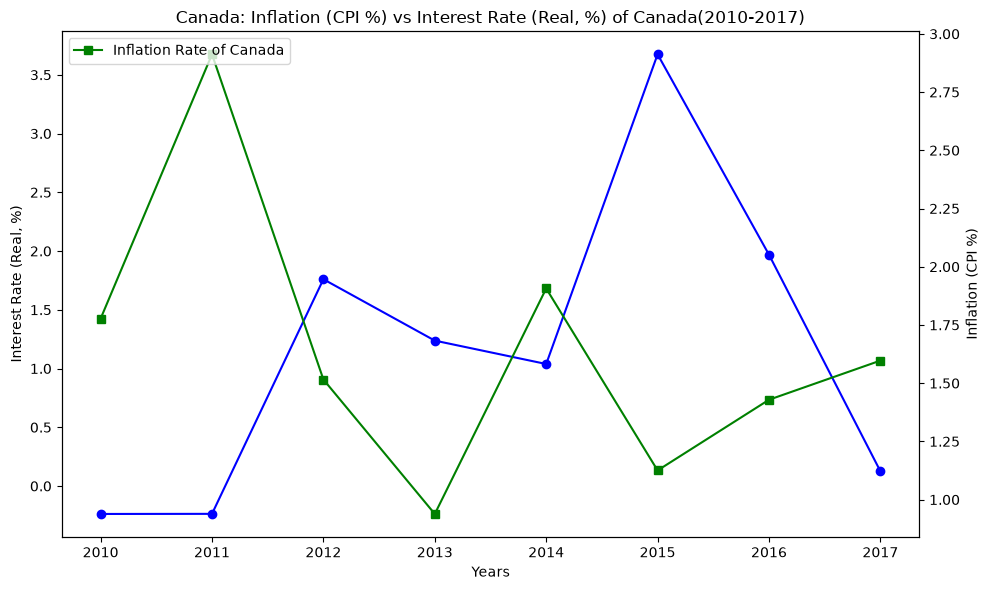

In [13]:
#Step 3 is Exploring data by focus on dataset of USA and Canada
#Time series analysis of Inflation Rate and Interest Rate of USA and Canada
year = [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017]
canadaInterest = colsAnalyze.loc[(colsAnalyze['country_name'] == 'Canada') & (colsAnalyze['year'].isin(year)), 'Interest Rate (Real, %)']
canadaInflation = colsAnalyze.loc[(colsAnalyze['country_name'] == 'Canada') & (colsAnalyze['year'].isin(year)), 'Inflation (CPI %)']

fig, ax = plt.subplots(figsize=(10, 6))

ax.set_ylabel("Interest Rate (Real, %)")
ax.set_xlabel("Years")
ax2 = ax.twinx()
ax2.set_ylabel("Inflation (CPI %)")

ax.plot(year, canadaInterest, color='blue', marker='o', label='Interest Rate of Canada')
ax2.plot(year, canadaInflation, color='green', marker='s', linestyle='-', label='Inflation Rate of Canada')
# ax.plot(year, usaInflation, color='red', marker='s', linestyle='-', label='USA')
ax.set_title("Canada: Inflation (CPI %) vs Interest Rate (Real, %) of Canada(2010-2017)")
plt.tight_layout()
plt.legend(loc='upper left')
plt.show()



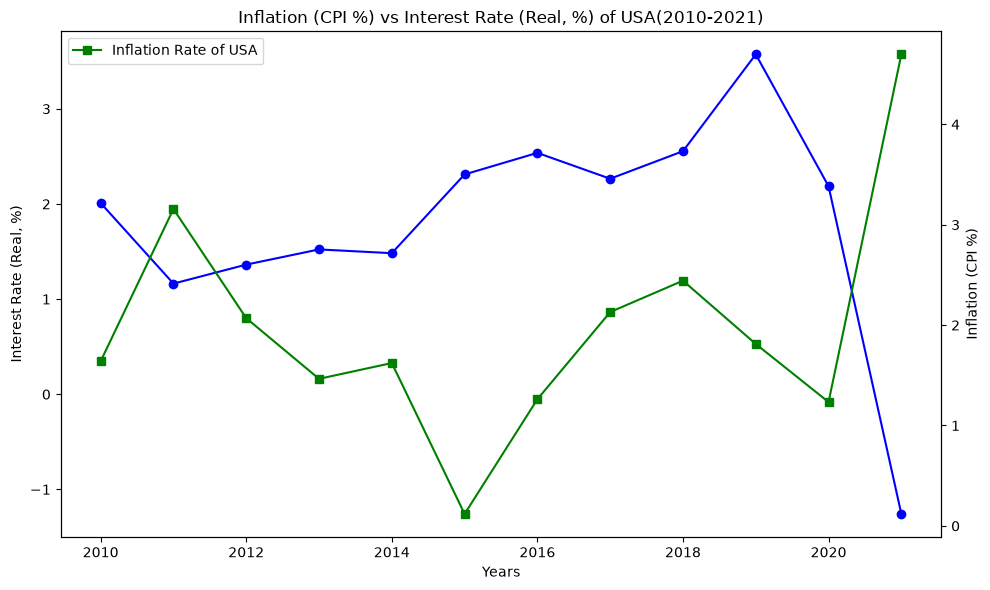

In [ ]:
yearUSA = [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
usaInterest = colsAnalyze.loc[(colsAnalyze['country_name'] == 'United States') & (colsAnalyze['year'].isin(yearUSA)), 'Interest Rate (Real, %)']
usaInflation = colsAnalyze.loc[(colsAnalyze['country_name'] == 'United States') & (colsAnalyze['year'].isin(yearUSA)), 'Inflation (CPI %)']

fig, axUSA = plt.subplots(figsize=(10, 6))

axUSA.set_ylabel("Interest Rate (Real, %)")
axUSA.set_xlabel("Years")
axUSA2 = axUSA.twinx()
axUSA2.set_ylabel("Inflation (CPI %)")

axUSA.plot(yearUSA, usaInterest, color='blue', marker='o', label='Interest Rate of USA')
axUSA2.plot(yearUSA, usaInflation, color='green', marker='s', linestyle='-', label='Inflation Rate of USA')
# ax.plot(year, usaInflation, color='red', marker='s', linestyle='-', label='USA')
axUSA.set_title("Inflation (CPI %) vs Interest Rate (Real, %) of USA(2010-2021)")
plt.tight_layout()
plt.legend(loc='upper left')
plt.show()


# Country-Level Average Indicators

To obtain a high-level view of each country’s macroeconomic environment, we calculate the mean of each indicator across the available years (2010–2023).  

These averages reveal large differences across the world: many emerging-market economies show higher average inflation and more volatile growth, while advanced economies tend to have lower and more stable inflation together with lower unemployment. This global heterogeneity is one reason why country-specific time-series analysis is more informative than a simple pooled correlation.

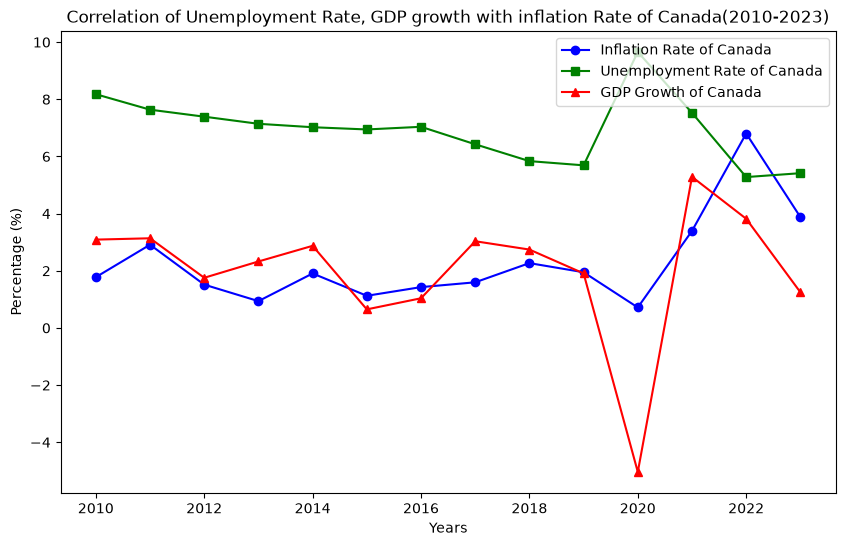

In [7]:
year = [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]

InflationCanadaX = colsAnalyze.loc[(colsAnalyze['country_name'] == 'Canada') & (colsAnalyze['year'].isin(year)), 'Inflation (CPI %)']
UnemploymentCanadaX = colsAnalyze.loc[(colsAnalyze['country_name'] == 'Canada') & (colsAnalyze['year'].isin(year)), 'Unemployment Rate (%)']
gdpGrowthCanadaX = colsAnalyze.loc[(colsAnalyze['country_name'] == 'Canada') & (colsAnalyze['year'].isin(year)), 'GDP Growth (% Annual)']

plt.figure(figsize=(10, 6))
plt.plot(year, InflationCanadaX, color='blue', marker='o', label='Inflation Rate of Canada')
plt.plot(year, UnemploymentCanadaX, color='green', marker='s', label='Unemployment Rate of Canada')
plt.plot(year, gdpGrowthCanadaX, color='red', marker='^', label='GDP Growth of Canada')
plt.legend(loc='upper right')
plt.title("Correlation of Unemployment Rate, GDP growth with inflation Rate of Canada(2010-2023)")
plt.xlabel("Years")
plt.ylabel("Percentage (%)")
plt.show()

#conclusion: The unemployment rate of Canada is have contrast rate with the inflation rate of Canada. 
#While the GDP growth rate of Canada is have same rate with the inflation rate of Canada.
#In covid period, 2019-2021, the unemployment rate of Canada is high, while the inflation rate of Canada is low and GDP growth dropped dramatically.
#That shows the unemployment rate affect on the inflation rate, and the inflation drop that cause the dropping of gpd growth rate.

# Time-Series Analysis: Canada (2010–2023)

Canada offers a useful comparison: a high-income open economy that is closely linked to the United States but has its own independent monetary policy (Bank of Canada).

**Main observations:**

- Before COVID, the patterns are similar to those in the United States: declining unemployment, moderate inflation, and positive GDP growth.
- In 2020, unemployment rose sharply and GDP growth turned deeply negative, while inflation stayed subdued.
- The post-pandemic recovery also brought a clear inflation spike that peaked in 2022, followed by a gradual decline in 2023.

Overall, the inverse relationship between unemployment and inflation, and the positive co-movement of GDP growth and inflation, are visible in the Canadian data as well.

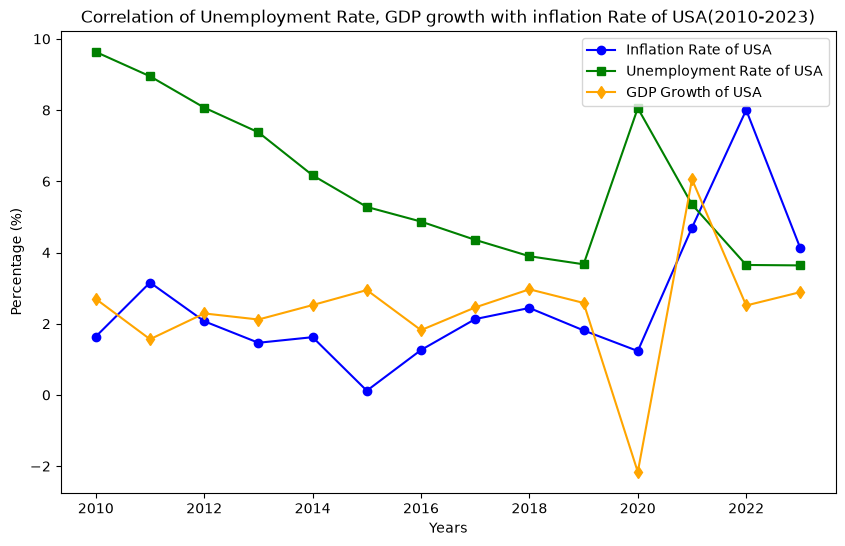

In [8]:
year = [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]

InflationUSA = colsAnalyze.loc[(colsAnalyze['country_name'] == 'United States') & (colsAnalyze['year'].isin(year)), 'Inflation (CPI %)']
UnemploymentUSA= colsAnalyze.loc[(colsAnalyze['country_name'] == 'United States') & (colsAnalyze['year'].isin(year)), 'Unemployment Rate (%)']
gdpGrowthUSA = colsAnalyze.loc[(colsAnalyze['country_name'] == 'United States') & (colsAnalyze['year'].isin(year)), 'GDP Growth (% Annual)']

plt.figure(figsize=(10, 6))
plt.plot(year, InflationUSA, color='blue', marker='o', label='Inflation Rate of USA')
plt.plot(year, UnemploymentUSA, color='green', marker='s', label='Unemployment Rate of USA')
plt.plot(year, gdpGrowthUSA, color='orange', marker='d', label='GDP Growth of USA')
plt.legend(loc='upper right')
plt.title("Correlation of Unemployment Rate, GDP growth with inflation Rate of USA(2010-2023)")
plt.xlabel("Years")
plt.ylabel("Percentage (%)")
plt.show()

#conclusion: The unemployment rate of USA is have contrast rate with the inflation rate of USA. 
#While the GDP growth rate of USA is have same rate with the inflation rate of USA.
#In covid period, 2019-2021 the inflation rate of USA is low casusing global economic that causing high value of unemployment and dropping the value of GDP growth dramatically.
#That shows the unemployment rate affect on the inflation rate, and the inflation drop that cause the dropping of gpd growth rate.

# Time-Series Analysis: United States (2010–2023)

The United States is the world’s largest economy and provides a clear illustration of the relationships we are interested in.

**Main observations:**

- **2010–2019 (expansion period)**  
  Unemployment declined steadily from roughly 9.6% to 3.7%. Inflation stayed moderate, mostly between 1% and 2.5%. GDP growth was positive but relatively modest.

- **2020 (COVID-19 shock)**  
  GDP growth collapsed to about –2.2%, unemployment jumped to 8.1%, and inflation remained low (around 1.2%). This pattern is typical of a large demand shock.

- **2021–2022 (recovery and inflation surge)**  
  GDP rebounded strongly (+6.1% in 2021). Unemployment fell quickly, while inflation rose to 4.7% in 2021 and then to 8.0% in 2022 — the highest reading in four decades.

- **2023**  
  Inflation moderated to around 4.1%, unemployment stayed low (approximately 3.6%), and growth remained positive.

**Interpretation**  
Outside the pandemic period, unemployment and inflation move in roughly opposite directions, consistent with a short-run Phillips-curve relationship. GDP growth and inflation tend to move together during demand-driven episodes. The 2020 shock temporarily broke these regularities; the strong recovery that followed then produced a clear inflation overshoot.

# Conclusion

Time-series analysis of World Bank data for the United States and Canada (2010–2023) supports several classic macroeconomic relationships while also illustrating how a large exogenous shock can temporarily disrupt them.

**Main findings:**

1. **Unemployment and inflation**  
   Outside the pandemic period the two series generally move in opposite directions, consistent with a short-run Phillips-curve relationship. High unemployment in 2020 coincided with low inflation; the subsequent labour-market recovery was accompanied by rising inflation.

2. **GDP growth and inflation**  
   Strong growth episodes — especially the sharp rebound in 2021 — are associated with higher inflation, pointing to demand-side pressure as an important driver.

3. **Real interest rates**  
   Real rates remained low through most of the 2010s and only turned more positive after the 2021–22 inflation surge. This pattern illustrates both the accommodative stance of monetary policy during the expansion and the lag in policy transmission.

4. **COVID-19 as a structural break**  
   The 2020 demand shock produced the textbook combination of collapsing growth, soaring unemployment, and subdued inflation. The rapid recovery that followed generated the strongest inflation episode in several decades.

Overall, the evidence is consistent with the view that inflation is influenced by both labour-market tightness and real economic activity, while monetary policy (via the real interest rate) responds with a lag.  

Future extensions of this work could include a larger set of countries, additional variables such as money growth or commodity prices, or formal econometric tests for Granger causality and structural breaks around 2020.

# Sources

1. World Bank Open Data – World Development Indicators. https://data.worldbank.org/
2. Phillips, A. W. (1958). The Relation between Unemployment and the Rate of Change of Money Wage Rates in the United Kingdom, 1861–1957. *Economica*.
3. Okun, A. M. (1962). Potential GNP: Its Measurement and Significance. American Statistical Association.
4. Bank of Canada and Federal Reserve historical monetary-policy documentation (public domain).